In [1]:
import torch
import ultralytics

print("--- SYSTEM DIAGNOSTICS ---")
print(f"PyTorch Version: {torch.__version__}")
print(f"Ultralytics Version: {ultralytics.__version__}\n")

cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
else:
    print("\n⚠️ WARNING: CUDA is NOT available!")
    print("Your models will train on the CPU, which is extremely slow.")

--- SYSTEM DIAGNOSTICS ---
PyTorch Version: 2.7.1+cu118
Ultralytics Version: 8.4.37

CUDA Available: True
GPU Device Name: NVIDIA GeForce RTX 3060
Number of GPUs: 1


In [3]:
import os

# --- UPDATE THIS TO YOUR MAIN RAF-DB FOLDER ---
# (The folder that contains the 'train' and 'test' subfolders)
DATASET_DIR = r'C:\Users\User\Desktop\AiAssignment\Ai-Assignment\RAF-DB'
# ----------------------------------------------

emotion_map = {
    '1': 'surprise', '2': 'fear', '3': 'disgust', 
    '4': 'happy', '5': 'sad', '6': 'angry', '7': 'neutral'
}

print("Renaming folders...")

for split in ['train', 'test']:
    split_dir = os.path.join(DATASET_DIR, split)
    
    # Check if the train/test folder exists
    if not os.path.exists(split_dir):
        print(f"⚠️ Could not find folder: {split_dir}")
        continue

    for folder_num, emotion_name in emotion_map.items():
        old_path = os.path.join(split_dir, folder_num)
        new_path = os.path.join(split_dir, emotion_name)
        
        # If the numbered folder exists, rename it
        if os.path.exists(old_path):
            os.rename(old_path, new_path)
            print(f"✅ Renamed: {split}/{folder_num} -> {split}/{emotion_name}")
        elif os.path.exists(new_path):
            print(f"ℹ️ Already named correctly: {split}/{emotion_name}")

print("\n🚀 Phase 1 Complete! Move straight to the Phase 2 Preprocessing script.")

Renaming folders...
✅ Renamed: train/1 -> train/surprise
✅ Renamed: train/2 -> train/fear
✅ Renamed: train/3 -> train/disgust
✅ Renamed: train/4 -> train/happy
✅ Renamed: train/5 -> train/sad
✅ Renamed: train/6 -> train/angry
✅ Renamed: train/7 -> train/neutral
✅ Renamed: test/1 -> test/surprise
✅ Renamed: test/2 -> test/fear
✅ Renamed: test/3 -> test/disgust
✅ Renamed: test/4 -> test/happy
✅ Renamed: test/5 -> test/sad
✅ Renamed: test/6 -> test/angry
✅ Renamed: test/7 -> test/neutral

🚀 Phase 1 Complete! Move straight to the Phase 2 Preprocessing script.


In [6]:
import os
import cv2
import numpy as np
import glob

# --- UPDATE THIS PATH TO YOUR NEW RAF-DB TRAIN FOLDER ---
TRAIN_DIR = r'C:\Users\User\Desktop\AiAssignment\Ai-Assignment\RAF-DB\train'
# --------------------------------------------------------

def preprocess_and_augment(img):
    """Applies noise reduction and random augmentation."""
    # 1. Noise Reduction (Gaussian Blur)
    blurred = cv2.GaussianBlur(img, (3, 3), 0)
    
    # 2. Random Horizontal Flip
    if np.random.rand() > 0.5:
        blurred = cv2.flip(blurred, 1)
        
    # 3. Random Brightness (Simulates different lighting) safely
    value = np.random.randint(-20, 20)
    
    # Cast to int32 to safely do math beyond the 0-255 limits
    blurred_int = blurred.astype(np.int32)
    blurred_int = blurred_int + value
    
    # Force everything back into the 0-255 range
    blurred_clipped = np.clip(blurred_int, 0, 255)
    
    return blurred_clipped.astype(np.uint8)

emotions = os.listdir(TRAIN_DIR)
class_counts = {}

# Step 1: Find the target count (the size of the largest class)
for emotion in emotions:
    folder_path = os.path.join(TRAIN_DIR, emotion)
    if os.path.isdir(folder_path):
        class_counts[emotion] = len(glob.glob(os.path.join(folder_path, '*.jpg')))

TARGET_COUNT = max(class_counts.values())
print(f"🎯 Target balance count set to: {TARGET_COUNT} images per class")

# Step 2: Augment minority classes
for emotion in emotions:
    folder_path = os.path.join(TRAIN_DIR, emotion)
    if not os.path.isdir(folder_path): continue
        
    images = glob.glob(os.path.join(folder_path, '*.jpg'))
    current_count = len(images)
    shortfall = TARGET_COUNT - current_count
    
    if shortfall > 0:
        print(f" -> {emotion.upper()}: Generating {shortfall} synthetic images...")
        generated = 0
        while generated < shortfall:
            random_img_path = np.random.choice(images)
            img = cv2.imread(random_img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None: continue
            
            # Ensure 100x100 resolution
            img = cv2.resize(img, (100, 100))
            final_img = preprocess_and_augment(img)
            
            new_filename = f"aug_{generated}_{os.path.basename(random_img_path)}"
            cv2.imwrite(os.path.join(folder_path, new_filename), final_img)
            generated += 1
            
    # Step 3: Standardize the original images (Grayscale & 100x100)
    print(f" -> {emotion.upper()}: Standardizing original images...")
    for img_path in images:
        img = cv2.imread(img_path)
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            resized = cv2.resize(gray, (100, 100))
            cv2.imwrite(img_path, resized)

print("\n✅ RAF-DB Preprocessing Complete! Ready for Training.")

🎯 Target balance count set to: 4772 images per class
 -> ANGRY: Generating 4067 synthetic images...
 -> ANGRY: Standardizing original images...
 -> DISGUST: Generating 4055 synthetic images...
 -> DISGUST: Standardizing original images...
 -> FEAR: Generating 4491 synthetic images...
 -> FEAR: Standardizing original images...
 -> HAPPY: Standardizing original images...
 -> NEUTRAL: Generating 2248 synthetic images...
 -> NEUTRAL: Standardizing original images...
 -> SAD: Generating 2790 synthetic images...
 -> SAD: Standardizing original images...
 -> SURPRISE: Generating 3482 synthetic images...
 -> SURPRISE: Standardizing original images...

✅ RAF-DB Preprocessing Complete! Ready for Training.


In [9]:
from ultralytics import YOLO

# Load a fresh, pre-trained medium classification model
model = YOLO('yolov8m-cls.pt')

print("🚀 Initiating YOLOv8 Training Sequence on RAF-DB...")

# --- UPDATE THIS PATH to your main RAF-DB folder ---
# This folder MUST contain your 'train' and 'test' subfolders inside it.
DATA_DIR = r'C:\Users\User\Desktop\AiAssignment\Ai-Assignment\RAF-DB'

# Train it on your new, clean dataset
results = model.train(
    data=DATA_DIR, 
    epochs=30, 
    imgsz=100,  # CRITICAL: Match the 100x100 resolution
    batch=64, 
    device=0    # RTX 3060 engaged
)

🚀 Initiating YOLOv8 Training Sequence on RAF-DB...
Ultralytics 8.4.37  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\User\Desktop\AiAssignment\Ai-Assignment\RAF-DB, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=100, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs


📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.85      0.74      0.79       162
     disgust       0.68      0.44      0.54       160
        fear       0.88      0.51      0.65        74
       happy       0.92      0.92      0.92      1185
     neutral       0.77      0.86      0.81       680
         sad       0.80      0.86      0.83       478
    surprise       0.85      0.83      0.84       329

    accuracy                           0.84      3068
   macro avg       0.82      0.74      0.77      3068
weighted avg       0.84      0.84      0.84      3068



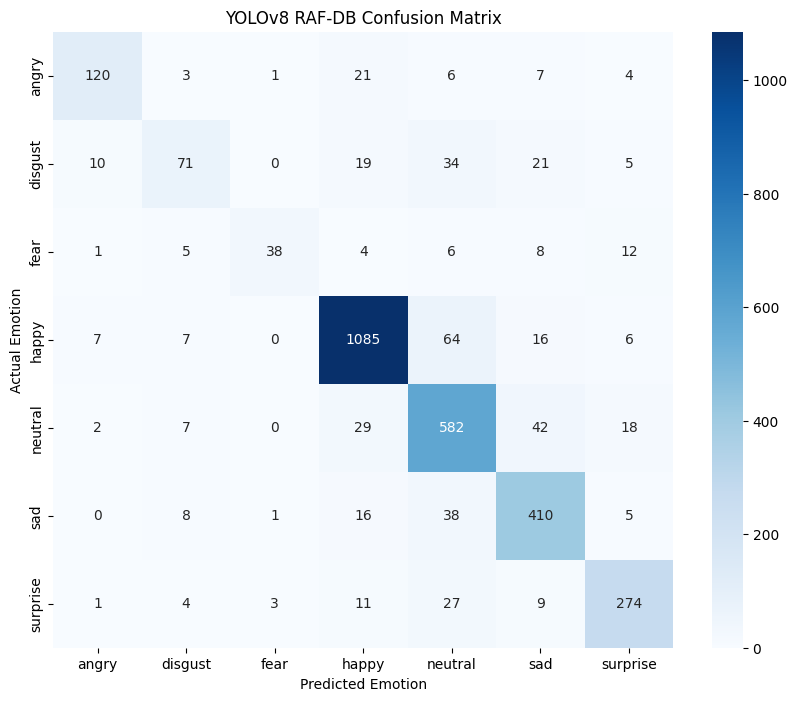

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix

# --- UPDATE THIS AFTER TRAINING FINISHES ---
MODEL_PATH = r'C:\Users\clogg\Desktop\School Github Repos\Ai-Assignment\runs\classify\train3\weights\best.pt'
TEST_DIR = r'C:\Users\clogg\Desktop\School Github Repos\Ai-Assignment\RAF-DB\test'
# ------------------------------------------

model = YOLO(MODEL_PATH)
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

y_true = []
y_pred = []

for emotion in class_names:
    folder_path = os.path.join(TEST_DIR, emotion)
    if not os.path.isdir(folder_path): continue
        
    for img_path in glob.glob(os.path.join(folder_path, '*.jpg')):
        results = model(img_path, verbose=False)
        pred_class = results[0].names[results[0].probs.top1]
        
        y_true.append(emotion)
        y_pred.append(pred_class)

print("\n" + "="*50)
print("📊 CLASSIFICATION REPORT")
print("="*50)
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

with open("classification_report.txt", "w") as text_file:
    text_file.write(report)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=class_names), annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('YOLOv8 RAF-DB Confusion Matrix')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.savefig('custom_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()